In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("cleaned_dropout_ratio.csv")
df

,State_UT,year,Primary_Boys,Primary_Girls,Primary_Total,Upper Primary_Boys,Upper Primary_Girls,Upper Primary_Total,Secondary _Boys,Secondary _Girls,Secondary _Total,HrSecondary_Boys,HrSecondary_Girls,HrSecondary_Total
0,A & N Islands,2012-13,0.83,0.51,0.68,NaN,1.09,1.23,5.57,5.55,5.56,17.66,10.15,14.14
1,A & N Islands,2013-14,1.35,1.06,1.21,NaN,1.54,0.51,8.36,5.98,7.20,18.94,12.20,15.87
2,A & N Islands,2014-15,0.47,0.55,0.51,1.44,1.95,1.69,11.47,8.16,9.87,21.05,12.21,16.93
3,Andhra Pradesh,2012-13,3.30,3.05,3.18,3.21,3.51,3.36,12.21,13.25,12.72,2.66,NaN,0.35
4,Andhra Pradesh,2013-14,4.31,4.39,4.35,3.46,4.12,3.78,11.95,13.37,12.65,12.65,10.85,11.79
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,West Bengal,2013-14,3.44,2.37,2.91,5.63,3.10,4.31,16.73,19.77,18.34,8.03,7.76,7.90
106,West Bengal,2014-15,2.13,0.79,1.47,5.84,2.88,4.30,16.33,19.06,17.80,8.18,8.04,8.11
107,All India,2012-13,4.68,4.66,4.67,2.30,4.01,3.13,14.54,14.54,14.54,NaN,NaN,NaN
108,All India,2013-14,4.53,4.14,4.34,3.09,4.49,3.77,17.93,17.79,17.86,1.48,1.61,1.54


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 110
Columns: 14


In [4]:
print(df.columns)

Index(['State_UT', 'year', 'Primary_Boys', 'Primary_Girls', 'Primary_Total',
       'Upper Primary_Boys', 'Upper Primary_Girls', 'Upper Primary_Total',
       'Secondary _Boys', 'Secondary _Girls', 'Secondary _Total',
       'HrSecondary_Boys', 'HrSecondary_Girls', 'HrSecondary_Total'],
      dtype='object')


In [5]:
print(df.isnull().sum())

State_UT                0
year                    0
Primary_Boys           15
Primary_Girls          15
Primary_Total          17
Upper Primary_Boys     17
Upper Primary_Girls     8
Upper Primary_Total     9
Secondary _Boys         4
Secondary _Girls        4
Secondary _Total        4
HrSecondary_Boys       28
HrSecondary_Girls      34
HrSecondary_Total      31
dtype: int64


In [6]:
print("Duplicate records:", df.duplicated().sum())

Duplicate records: 0


In [7]:
df.describe()

,Primary_Boys,Primary_Girls,Primary_Total,Upper Primary_Boys,Upper Primary_Girls,Upper Primary_Total,Secondary _Boys,Secondary _Girls,Secondary _Total,HrSecondary_Boys,HrSecondary_Girls,HrSecondary_Total
count,95.000000,95.000000,93.000000,93.000000,102.000000,101.000000,106.000000,106.000000,106.000000,82.000000,76.000000,79.000000
mean,4.971368,4.644105,4.908602,4.236667,4.496471,4.181089,17.809906,16.926981,17.393868,9.347317,7.206974,8.296329
std,4.683392,4.590296,4.617200,3.286495,3.364940,3.285638,8.435483,9.015808,8.609419,7.160002,5.213958,6.135895
min,0.000000,0.260000,0.200000,0.010000,0.000000,0.070000,5.570000,4.210000,5.320000,0.230000,0.300000,0.350000
25%,1.350000,1.120000,1.290000,2.370000,2.242500,1.790000,11.740000,9.832500,10.587500,3.097500,3.685000,3.375000
50%,3.630000,3.250000,3.580000,3.490000,3.855000,3.800000,16.340000,15.290000,15.445000,8.290000,5.850000,7.640000
75%,7.000000,6.635000,6.790000,5.630000,6.122500,5.550000,23.342500,22.540000,23.345000,13.422500,9.715000,11.520000
max,24.270000,23.930000,24.110000,19.350000,19.210000,19.280000,50.090000,49.620000,49.860000,44.380000,36.050000,40.480000


In [9]:
print(df.columns.tolist())

['State_UT', 'year', 'Primary_Boys', 'Primary_Girls', 'Primary_Total', 'Upper Primary_Boys', 'Upper Primary_Girls', 'Upper Primary_Total', 'Secondary _Boys', 'Secondary _Girls', 'Secondary _Total', 'HrSecondary_Boys', 'HrSecondary_Girls', 'HrSecondary_Total']


In [10]:
levels = [
    "Primary_Total",
    "Upper Primary_Total",
    "Secondary _Total",
    "HrSecondary_Total"
]

print(df[levels].mean())

Primary_Total           4.908602
Upper Primary_Total     4.181089
Secondary _Total       17.393868
HrSecondary_Total       8.296329
dtype: float64


In [11]:
yearly = df.groupby("year")[levels].mean()
print(yearly)

         Primary_Total  Upper Primary_Total  Secondary _Total  \
year                                                            
2012-13       5.354138             4.277742         16.602353   
2013-14       4.919394             4.284000         18.240556   
2014-15       4.480323             3.992571         17.294722   

         HrSecondary_Total  
year                        
2012-13           7.839583  
2013-14           8.573333  
2014-15           8.420714  


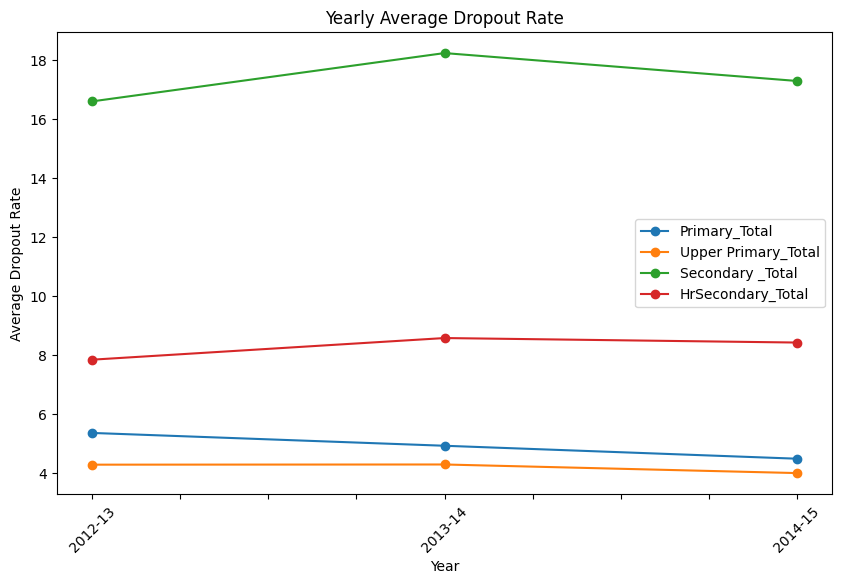

In [12]:
import matplotlib.pyplot as plt

yearly.plot(marker="o", figsize=(10,6))

plt.title("Yearly Average Dropout Rate")
plt.xlabel("Year")
plt.ylabel("Average Dropout Rate")
plt.xticks(rotation=45)
plt.legend()
plt.show()

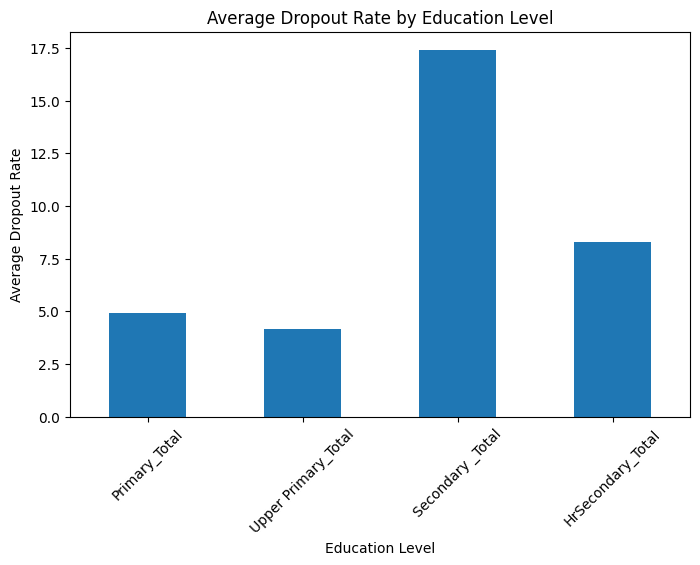

In [13]:
df[levels].mean().plot(kind="bar", figsize=(8,5))

plt.title("Average Dropout Rate by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Average Dropout Rate")
plt.xticks(rotation=45)
plt.show()

In [16]:
highest = df.loc[df["Secondary _Total"].idxmax()]

print("State:", highest["State_UT"])
print("Year:", highest["year"])
print("Secondary Dropout:", highest["Secondary _Total"])

State: Odisha
Year: 2012-13
Secondary Dropout: 49.86


In [17]:
print(df[levels].isnull().sum())

Primary_Total          17
Upper Primary_Total     9
Secondary _Total        4
HrSecondary_Total      31
dtype: int64


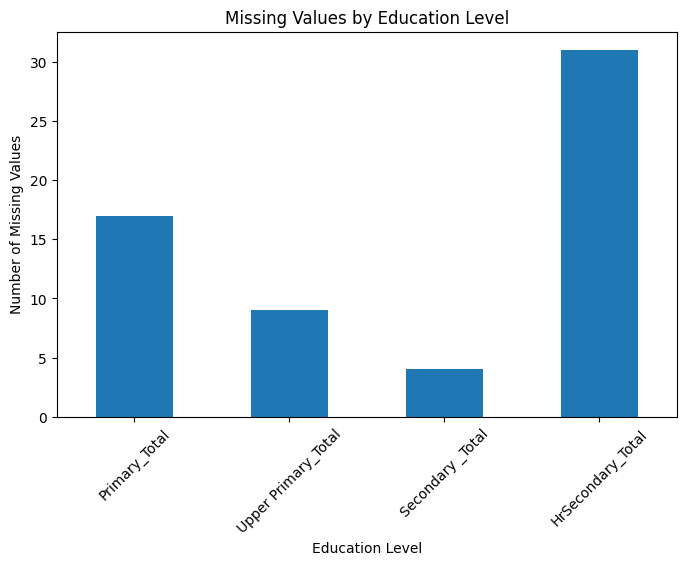

In [18]:
df[levels].isnull().sum().plot(kind="bar", figsize=(8,5))

plt.title("Missing Values by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.show()

In [19]:
print("5 Useful Insights:")

print("1. Secondary education has the highest average dropout rate.")

print("2. Primary dropout rate decreased over the years.")

print("3. Secondary dropout rate shows a slight increase over the years.")

print("4. Some records have unusually high dropout values.")

print("5. Higher Secondary has the highest number of missing values among the four total dropout columns.")

5 Useful Insights:
1. Secondary education has the highest average dropout rate.
2. Primary dropout rate decreased over the years.
3. Secondary dropout rate shows a slight increase over the years.
4. Some records have unusually high dropout values.
5. Higher Secondary has the highest number of missing values among the four total dropout columns.
